[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/comptelab/BIORTC_Nigeria/blob/main/2026/Workshops/EEG/EEG_01_Preprocessing.ipynb)

# EEG Sensor-Level Analysis - Preprocessing
### BioRTC 2026 · Simons Computational Neuroscience Summer School · Yobe State University

---

This notebook walks through the complete sensor-level EEG analysis pipeline introduced in the lecture, applied to a real focal seizure recording from the **TUH EEG Artifact Corpus (TUAR v3.0.1)**.

**To apply this to a different recording:** change only the paths in the cell `Configuration` and re-run all cells.

**Contents**
1. Load & explore the EDF file
2. Read TUAR annotations (artifacts + seizure)
3. Filtering: bandpass + notch
4. The 1/f problem - power spectral density
5. Time-frequency analysis - absolute spectrogram
6. Baseline normalization - removing 1/f
7. Band power: pre / ictal / post comparison
8. Your turn! - apply to a new recording

In [6]:
# Install missing packages when running on Google Colab
try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    %pip install -q mne

In [ ]:
# Download the required TUAR recording from the course GitHub repo when running on Google Colab
if IN_COLAB:
    import os, urllib.request

    BASE_URL = 'https://raw.githubusercontent.com/comptelab/BIORTC_Nigeria/main/2026/Data/TUH_EEG_Corpus/tuar/v3.0.1/edf/01_tcp_ar'
    BNAME = 'aaaaakbz_s001_t000'
    local_dir = 'TUH_EEG_Corpus/tuar/v3.0.1/edf/01_tcp_ar'
    os.makedirs(local_dir, exist_ok=True)

    for ext in ['.edf', '.csv', '_seiz.csv']:
        local_path = os.path.join(local_dir, BNAME + ext)
        if not os.path.exists(local_path):
            urllib.request.urlretrieve(f'{BASE_URL}/{BNAME}{ext}', local_path)
        print(f'{"OK  " if os.path.exists(local_path) else "MISS"} {local_path}')

In [7]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import mne
from scipy import signal as sp
import warnings
warnings.filterwarnings('ignore')
mne.set_log_level('WARNING')

%matplotlib inline
plt.rcParams['figure.dpi'] = 110

---
## Configuration

**Change only `SUBDIR`, `BNAME`, and `FOCUS_CH` to analyse a different recording.**  
Seizure timing is read automatically from the `_seiz.csv` file.


In [8]:
# ── Paths ────────────────────────────────────────────────────────────────────
TUAR_ROOT = 'TUH_EEG_Corpus/tuar/v3.0.1/edf'

# Recording to analyse
SUBDIR  = '01_tcp_ar'
BNAME   = 'aaaaakbz_s001_t000'         # base name (no extension)

EDF_PATH  = os.path.join(TUAR_ROOT, SUBDIR, BNAME + '.edf')
ART_CSV   = os.path.join(TUAR_ROOT, SUBDIR, BNAME + '.csv')       # artifact labels
SEIZ_CSV  = os.path.join(TUAR_ROOT, SUBDIR, BNAME + '_seiz.csv')  # seizure labels

# ── Analysis channel (for single-channel plots) ──────────────────────────────
# Chosen by largest ictal/control power ratio in this recording (P3: ~176x vs T3: ~36x).
# TUAR's seizure annotation is identical across all channels - it carries no spatial
# information, so this is a data-driven pick, not a localization claim.
FOCUS_CH = 'EEG P3-REF'

print(f'EDF  : {EDF_PATH}')
print(f'Exist: {os.path.exists(EDF_PATH)}')

EDF  : TUH_EEG_Corpus/tuar/v3.0.1/edf/01_tcp_ar/aaaaakbz_s001_t000.edf
Exist: True


---
## The Data: TUH EEG Corpus (TUEG)

> **Workshop slides:** *"The TUH EEG Corpus"*, *"TUAR Annotation Labels"*, *"Referential EDF vs. Bipolar CSV"* in `EEG_Workshop_Support.pdf`.

**Folder structure** — we use `01_tcp_ar` throughout (average reference, >90% of recordings):
```
tuar/v3.0.1/edf/
├── 01_tcp_ar/    ← use this
├── 02_tcp_le/
└── 03_tcp_ar_a/
```

**File naming:** `aaaaacyf_s009_t001` = patient ID (`aaaaacyf`) + session (`s009`) + token (`t001`). Each base name has a `.edf` (signal) and a `.csv` (annotations).

**Channel name mismatch - important:** EDF stores referential channels (`EEG FP1-REF`); annotation CSVs use bipolar pairs (`FP1-F7`). You cannot directly match them - `FP1-F7` means `EEG FP1-REF` minus `EEG F7-REF`.

In [9]:
# Explore the local TUAR corpus: count recordings and seizure files
import glob

for subdir in ["01_tcp_ar", "02_tcp_le", "03_tcp_ar_a"]:
    path = os.path.join(TUAR_ROOT, subdir)
    if not os.path.isdir(path):
        continue
    edfs  = glob.glob(os.path.join(path, "*.edf"))
    seiz  = glob.glob(os.path.join(path, "*_seiz.csv"))
    print(f"{subdir}: {len(edfs):3d} EDF files, {len(seiz):3d} with seizure annotations")



01_tcp_ar: 290 EDF files,  29 with seizure annotations
02_tcp_le:  13 EDF files,   9 with seizure annotations
03_tcp_ar_a:   7 EDF files,   4 with seizure annotations


In [10]:
# Read seizure onset/offset from the annotation file
if os.path.exists(SEIZ_CSV):
    _sz = pd.read_csv(SEIZ_CSV, comment='#',
                      names=['channel', 'start', 'stop', 'label', 'confidence'])
    _sz['start'] = pd.to_numeric(_sz['start'], errors='coerce')
    _sz['stop']  = pd.to_numeric(_sz['stop'],  errors='coerce')
    _sz = _sz.dropna(subset=['start', 'stop'])
    _sz_events = _sz[_sz['label'] != 'bckg'].drop_duplicates(subset=['start', 'stop'])
    if len(_sz_events):
        print('Seizure events in this recording:')
        for i, row in _sz_events.reset_index(drop=True).iterrows():
            print(f'  #{i+1}: {row["start"]}s – {row["stop"]}s  '
                  f'({row["stop"]-row["start"]:.0f}s, {row["label"]})')
        SZ_ONSET  = float(_sz_events.iloc[0]['start'])
        SZ_OFFSET = float(_sz_events.iloc[0]['stop'])
        print(f'→ Using #1: SZ_ONSET={SZ_ONSET}s, SZ_OFFSET={SZ_OFFSET}s')
    else:
        SZ_ONSET = SZ_OFFSET = None
        print('No seizure annotation found in _seiz.csv.')
else:
    SZ_ONSET = SZ_OFFSET = None
    print('No _seiz.csv — treating as background-only recording.')


Seizure events in this recording:
  #1: 439.12s – 505.12s  (66s, cpsz)
  #2: 940.02s – 1058.0458s  (118s, cpsz)
→ Using #1: SZ_ONSET=439.12s, SZ_OFFSET=505.12s


---
## Section 1 - Load & Explore

In [11]:
raw = mne.io.read_raw_edf(EDF_PATH, preload=True)

sfreq    = raw.info['sfreq']
n_ch     = len(raw.ch_names)
duration = raw.times[-1]

print(f'Channels     : {n_ch}')
print(f'Sampling rate: {sfreq} Hz')
print(f'Duration     : {duration:.1f} s  ({duration/60:.1f} min)')
print(f'Channel names: {raw.ch_names}')

Channels     : 36
Sampling rate: 250.0 Hz
Duration     : 1442.0 s  (24.0 min)
Channel names: ['EEG FP1-REF', 'EEG FP2-REF', 'EEG F3-REF', 'EEG F4-REF', 'EEG C3-REF', 'EEG C4-REF', 'EEG P3-REF', 'EEG P4-REF', 'EEG O1-REF', 'EEG O2-REF', 'EEG F7-REF', 'EEG F8-REF', 'EEG T3-REF', 'EEG T4-REF', 'EEG T5-REF', 'EEG T6-REF', 'EEG A1-REF', 'EEG A2-REF', 'EEG FZ-REF', 'EEG CZ-REF', 'EEG PZ-REF', 'EEG ROC-REF', 'EEG LOC-REF', 'EEG EKG1-REF', 'EMG-REF', 'EEG 26-REF', 'EEG 27-REF', 'EEG 28-REF', 'EEG 29-REF', 'EEG 30-REF', 'EEG T1-REF', 'EEG T2-REF', 'PHOTIC-REF', 'IBI', 'BURSTS', 'SUPPR']


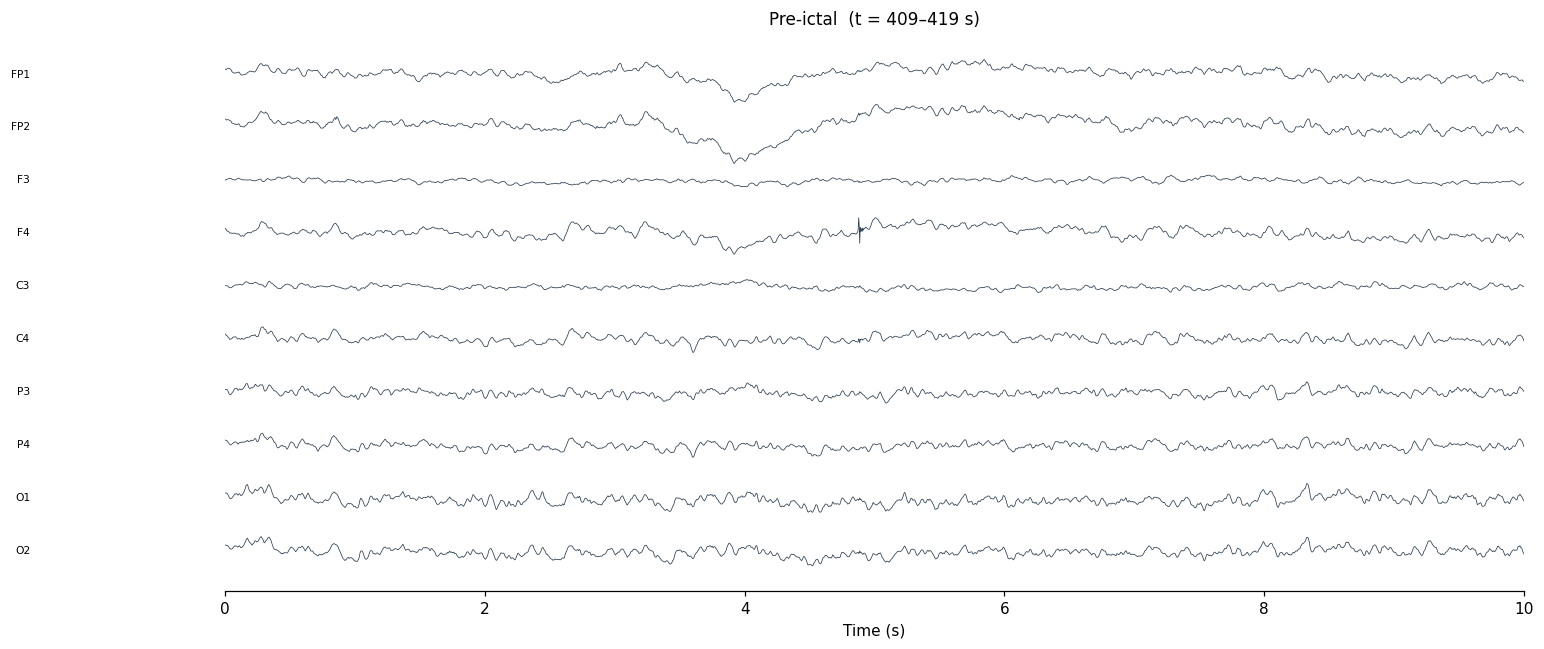

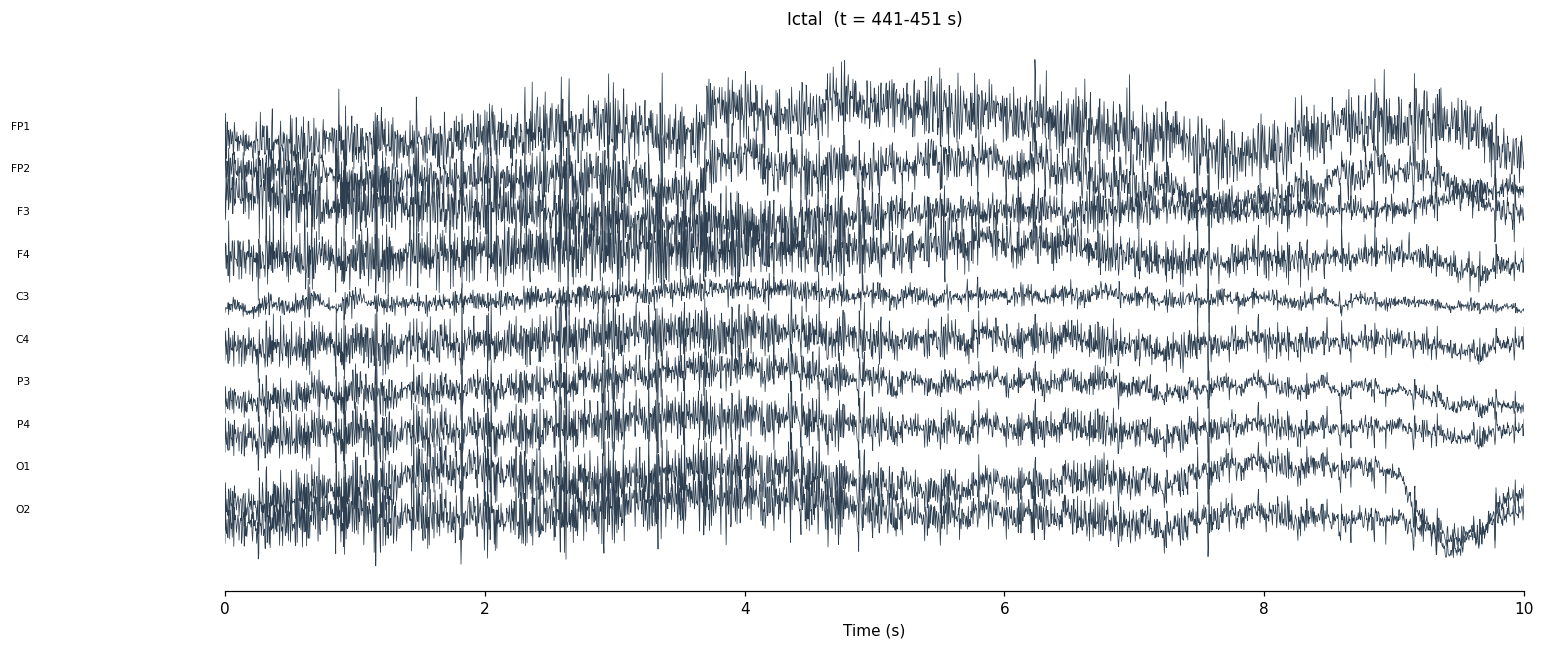

In [12]:
# Plot two 10-second windows: one pre-seizure, one ictal
# We use a simple butterfly-style stacked plot (MNE's raw.plot() needs a display)

def plot_eeg_stack(raw, t_start, duration_s=10, title='', n_ch_show=10, scale_uv=150):
    """Stacked multichannel EEG plot, offset by channel index."""
    i0 = int(t_start * sfreq)
    i1 = int((t_start + duration_s) * sfreq)
    data = raw.get_data()[:n_ch_show, i0:i1] * 1e6   # µV
    t    = np.linspace(0, duration_s, data.shape[1])

    fig, ax = plt.subplots(figsize=(14, 6))
    for k, (sig, name) in enumerate(zip(data, raw.ch_names[:n_ch_show])):
        offset = (n_ch_show - 1 - k) * scale_uv
        ax.plot(t, sig + offset, lw=0.5, color='#2c3e50')
        ax.text(-0.15, offset, name.replace('EEG ','').replace('-REF',''),
                ha='right', va='center', fontsize=7, transform=ax.get_yaxis_transform())
    ax.set_xlabel('Time (s)')
    ax.set_yticks([])
    ax.set_xlim(0, duration_s)
    ax.spines[['left','top','right']].set_visible(False)
    ax.set_title(title, fontsize=11)
    plt.tight_layout()
    plt.show()

if SZ_ONSET is not None:
    plot_eeg_stack(raw, SZ_ONSET - 30, duration_s=10,
                  title=f'Pre-ictal  (t = {SZ_ONSET-30:.0f}–{SZ_ONSET-20:.0f} s)')
    plot_eeg_stack(raw, SZ_ONSET + 2,  duration_s=10,
                  title=f'Ictal  (t = {SZ_ONSET+2:.0f}-{SZ_ONSET+12:.0f} s)')
else:
    plot_eeg_stack(raw, 60, duration_s=10, title='EEG segment (t = 60–70 s)')

---
## Section 2 - TUAR Annotations

> **Workshop slide:** *"TUAR Annotation Labels"* - artifact labels, seizure labels, CSV format difference.

Two CSV files per recording: `bname.csv` (artifact labels) and `bname_seiz.csv` (seizure labels). Both use the same format: `channel, start_time, stop_time, label, confidence`.

In [13]:
def read_tuar_csv(path):
    """Read a TUAR annotation CSV (skips comment lines starting with #)."""
    df = pd.read_csv(path, comment="#",
                     names=["channel","start","stop","label","confidence"])
    df["start"] = pd.to_numeric(df["start"], errors="coerce")
    df["stop"]  = pd.to_numeric(df["stop"],  errors="coerce")
    return df.dropna(subset=["start","stop"])

art_df  = read_tuar_csv(ART_CSV)
seiz_df = read_tuar_csv(SEIZ_CSV) if os.path.exists(SEIZ_CSV) else None

print("=== Artifact annotations (first 10 rows) ===")
print(art_df.head(10).to_string(index=False))
print(f"Unique artifact labels: {sorted(art_df['label'].unique())}")

if seiz_df is not None:
    print(f"=== Seizure annotations ===")
    print(seiz_df[seiz_df["channel"] == seiz_df["channel"].iloc[0]].to_string(index=False))


=== Artifact annotations (first 10 rows) ===
channel    start     stop     label confidence
 FP1-F7  57.1974  64.0083      eyem     1.0000
 FP1-F7  66.2922  67.6793      eyem     1.0000
 FP1-F7 116.0498 118.1847      eyem     1.0000
 FP1-F7 118.9159 122.0741      eyem     1.0000
 FP1-F7 122.4594 125.6781      eyem     1.0000
 FP1-F7 125.9336 130.0597      eyem     1.0000
 FP1-F7 183.6461 185.5667      eyem     1.0000
 FP1-F7 428.0077 429.8156 eyem_musc     1.0000
 FP1-F7 432.8447 435.2513 eyem_musc     1.0000
 FP1-F7 435.2876 510.9147 musc_elec     1.0000
Unique artifact labels: ['elec', 'eyem', 'eyem_musc', 'musc', 'musc_elec']
=== Seizure annotations ===
channel     start      stop label confidence
 FP1-F7    0.0000  439.1200  bckg     1.0000
 FP1-F7  439.1200  505.1200  cpsz     1.0000
 FP1-F7  505.1200  940.0200  bckg     1.0000
 FP1-F7  940.0200 1058.0458  cpsz     1.0000
 FP1-F7 1058.0458 1442.0000  bckg     1.0000


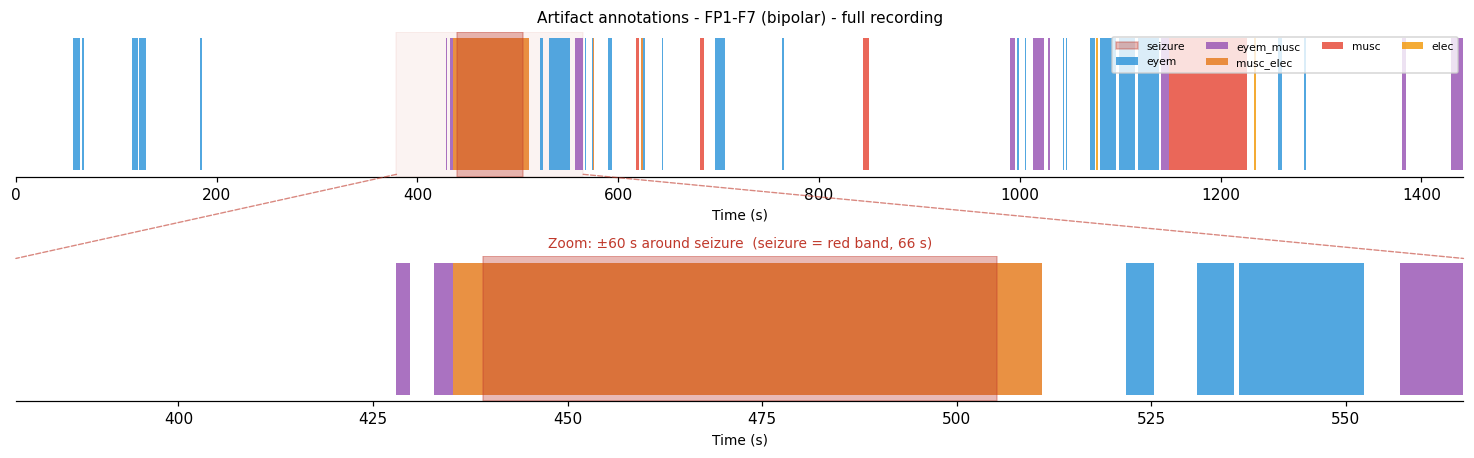

Recording duration : 1442 s  (24.0 min)
Seizure duration   : 66 s
Seizure fraction   : 4.6% of the recording

Note: seizures are rare, brief events — typically <5% of any EEG recording.
This extreme class imbalance is the core challenge in automated seizure detection.


In [14]:
from matplotlib.patches import ConnectionPatch

ARTIFACT_COLORS = {
    'eyem':      '#3498db',
    'musc':      '#e74c3c',
    'elec':      '#f39c12',
    'eyem_musc': '#9b59b6',
    'musc_elec': '#e67e22',
    'eyem_elec': '#1abc9c',
    'elpp':      '#2ecc71',
}

chan_art = art_df[art_df['channel'] == 'FP1-F7'].copy()
PAD = 60   # seconds shown on each side of seizure in zoom panel

def draw_timeline(ax, xlim):
    for _, row in chan_art.iterrows():
        col = ARTIFACT_COLORS.get(row['label'], '#888')
        ax.barh(0, row['stop'] - row['start'], left=row['start'],
                height=0.6, color=col, alpha=0.85, label=row['label'])
    if SZ_ONSET is not None:
        ax.axvspan(SZ_ONSET, SZ_OFFSET, color='#c0392b', alpha=0.35, label='seizure')
    ax.set_xlim(*xlim)
    ax.set_yticks([])
    ax.spines[['top','right','left']].set_visible(False)

fig, (ax_full, ax_zoom) = plt.subplots(
    2, 1, figsize=(14, 4.2),
    gridspec_kw={'height_ratios': [1, 1], 'hspace': 0.55})

# Full timeline
draw_timeline(ax_full, (0, duration))
ax_full.set_title('Artifact annotations - FP1-F7 (bipolar) - full recording', fontsize=10)

# Unique legend on full panel
handles, labels = ax_full.get_legend_handles_labels()
by_label = dict(zip(labels, handles))
ax_full.legend(by_label.values(), by_label.keys(), loc='upper right',
               fontsize=7, ncol=4, framealpha=0.8)

# Highlight zoom region on full panel
if SZ_ONSET is not None:
    ax_full.axvspan(SZ_ONSET - PAD, SZ_OFFSET + PAD,
                    color='#c0392b', alpha=0.06, zorder=0)
    ax_full.set_xlabel('Time (s)', fontsize=9)

# Zoom panel
if SZ_ONSET is not None:
    draw_timeline(ax_zoom, (SZ_ONSET - PAD, SZ_OFFSET + PAD))
    ax_zoom.set_xlabel('Time (s)', fontsize=9)
    ax_zoom.set_title(
        f'Zoom: ±{PAD} s around seizure  '
        f'(seizure = red band, {SZ_OFFSET-SZ_ONSET:.0f} s)',
        fontsize=9, color='#c0392b')

    # Connector lines between the two panels
    for x_full, x_zoom in [(SZ_ONSET - PAD, SZ_ONSET - PAD),
                            (SZ_OFFSET + PAD, SZ_OFFSET + PAD)]:
        con = ConnectionPatch(
            xyA=(x_full, -0.32), coordsA='data', axesA=ax_full,
            xyB=(x_zoom,  0.32), coordsB='data', axesB=ax_zoom,
            color='#c0392b', lw=0.9, ls='--', alpha=0.6)
        fig.add_artist(con)

fig.subplots_adjust(left=0.04, right=0.98, top=0.92, bottom=0.12, hspace=0.65)
plt.show()

if SZ_ONSET is not None:
    sz_pct = (SZ_OFFSET - SZ_ONSET) / duration * 100
    print(f'Recording duration : {duration:.0f} s  ({duration/60:.1f} min)')
    print(f'Seizure duration   : {SZ_OFFSET - SZ_ONSET:.0f} s')
    print(f'Seizure fraction   : {sz_pct:.1f}% of the recording')
    print()
    print('Note: seizures are rare, brief events — typically <5% of any EEG recording.')
    print('This extreme class imbalance is the core challenge in automated seizure detection.')

---
### Questions — Section 2: TUAR Annotations

**Q1.** Artifact annotations use bipolar channel names (e.g. `FP1-F7`) but the EDF stores
referential channels (`EEG FP1-REF`). You cannot directly look up an annotated channel name
in the EDF. What information do you need to map from bipolar labels to referential channels,
and how would you write that lookup in Python?

**Q2.** Some windows contain overlapping annotations of two artifact types simultaneously
(e.g. `eyem_musc` - eye movement plus muscle). If you want to exclude windows contaminated
by *any* artifact for a clean dataset, how would you modify the exclusion code? If you wanted
to keep windows where the artifact does NOT overlap with the seizure annotation, what
additional step would you add?

---
## Section 3 - Filtering

> **Workshop slide:** *"Filtering - Parameters and Pitfalls"* - bandpass choices, causal vs. zero-phase, and the 50/60 Hz notch difference.

Bandpass 0.5–70 Hz + notch. **Use 50 Hz for the Yobe recording** (`SUBJECT1.edf`); TUAR is US-acquired (60 Hz).

In [15]:
raw_filt = raw.copy().filter(l_freq=0.5, h_freq=70.0, verbose=False)
raw_filt.notch_filter(freqs=60.0, verbose=False)

print('Filtering done.')
print(f'Bandpass  : 0.5 - 70 Hz')
print(f'Notch     : 60 Hz')

Filtering done.
Bandpass  : 0.5 - 70 Hz
Notch     : 60 Hz


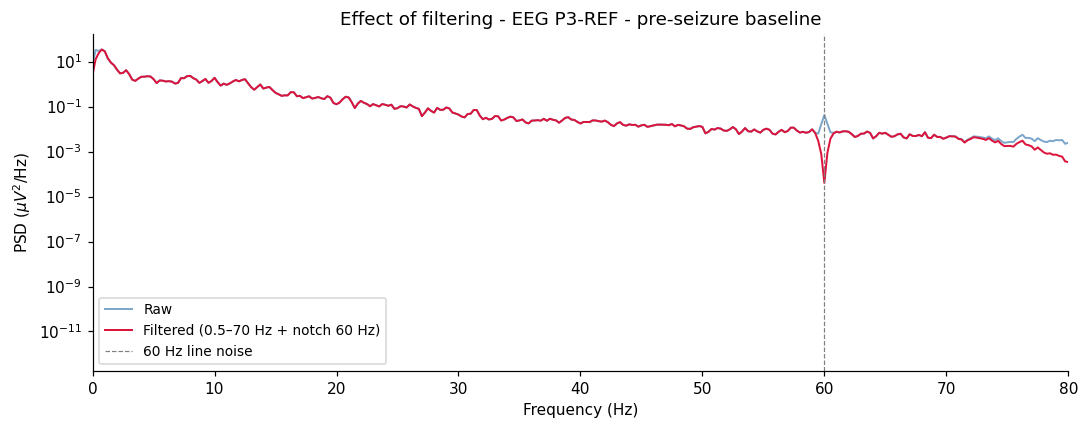

In [16]:
# Compare raw vs filtered PSD on a clean 60-second pre-seizure segment
ch_idx  = raw.ch_names.index(FOCUS_CH)
t0, t1  = (SZ_ONSET - 120, SZ_ONSET - 60) if SZ_ONSET else (60, 120)
i0, i1  = int(t0 * sfreq), int(t1 * sfreq)

seg_raw  = raw.get_data(picks=[ch_idx])[0, i0:i1]  * 1e6
seg_filt = raw_filt.get_data(picks=[ch_idx])[0, i0:i1] * 1e6

nperseg = int(4 * sfreq)
freqs, psd_raw  = sp.welch(seg_raw,  fs=sfreq, nperseg=nperseg)
freqs, psd_filt = sp.welch(seg_filt, fs=sfreq, nperseg=nperseg)

fig, ax = plt.subplots(figsize=(10, 4))
ax.semilogy(freqs, psd_raw,  color='steelblue',  lw=1.3, alpha=0.7, label='Raw')
ax.semilogy(freqs, psd_filt, color='crimson',    lw=1.3, label='Filtered (0.5–70 Hz + notch 60 Hz)')
ax.axvline(60, color='gray', ls='--', lw=0.8, label='60 Hz line noise')
ax.set_xlim(0, 80)
ax.set_xlabel('Frequency (Hz)')
ax.set_ylabel(r'PSD ($\mu V^2$/Hz)')
ax.set_title(f'Effect of filtering - {FOCUS_CH} - pre-seizure baseline')
ax.legend(fontsize=9)
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.show()

---
### Questions — Section 3: Filtering

**Q1.** The bandpass uses `l_freq=0.5 Hz` rather than 0 Hz (DC). Why? What artifact does
0.5 Hz remove, and what would happen to the time-domain EEG trace if you omitted this
high-pass filter and the recording has electrode drift?

**Q2.** The notch filter is set to 60 Hz (US mains). If you were analysing a recording
acquired in Nigeria (50 Hz mains), what would happen if you applied `notch_filter(60)`
instead of `notch_filter(50)`? What would you see in the PSD?

**Q3.** Causal FIR filters introduce a group delay - the filtered signal is shifted in time
relative to the original. MNE's default `filter()` is zero-phase (non-causal). Name one
situation in EEG analysis where using a non-causal filter would be methodologically
**incorrect**, and explain why.


---
## Section 4 - The 1/f Problem

> **Workshop slide:** *"The 1/f Problem - Quick Reference"* - P(f) ∝ 1/f^α, why absolute band power comparisons are meaningless, fix in Section 6.

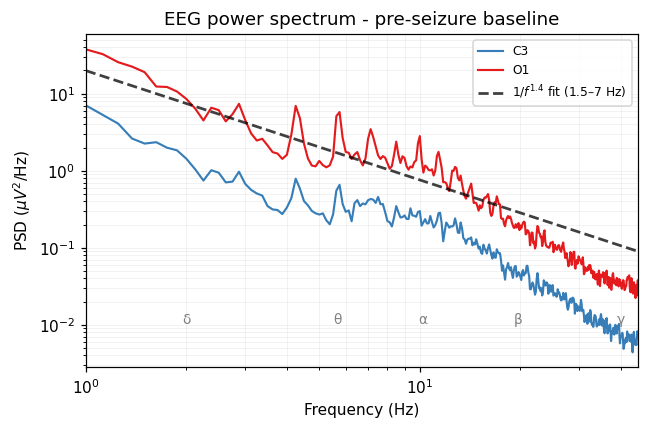

Fitted 1/f exponent α ≈ 1.42


In [17]:
# Use two channels away from the seizure focus for a clean 1/f demonstration
CLEAN_CHS = ['EEG C3-REF', 'EEG O1-REF']
COLORS    = ['#377eb8', '#e41a1c']

# Long clean pre-seizure window (50–300 s)
T0, T1 = 50.0, min(300.0, SZ_ONSET - 30 if SZ_ONSET else 300.0)
i0, i1 = int(T0 * sfreq), int(T1 * sfreq)

fig, ax = plt.subplots(figsize=(6, 4))

for ch_name, col in zip(CLEAN_CHS, COLORS):
    if ch_name not in raw_filt.ch_names:
        print(f'Channel {ch_name} not found — skipping')
        continue
    ch_i   = raw_filt.ch_names.index(ch_name)
    sig    = raw_filt.get_data(picks=[ch_i])[0, i0:i1] * 1e6
    freqs, psd = sp.welch(sig, fs=sfreq, nperseg=int(8 * sfreq),
                          noverlap=int(4 * sfreq))
    mask = (freqs >= 1) & (freqs <= 45)
    ax.semilogy(freqs[mask], psd[mask], color=col, lw=1.4,
                label=ch_name.replace('EEG ','').replace('-REF',''))

# Fit 1/f slope below the alpha peak (1.5–7 Hz) using the last channel
fit_mask = (freqs >= 1.5) & (freqs <= 7.0)
log_f = np.log10(freqs[fit_mask])
log_p = np.log10(psd[fit_mask])
alpha_fit, log_c = np.polyfit(log_f, log_p, 1)
c = 10 ** log_c
f_line = np.array([1.0, 45.0])
ax.plot(f_line, c * f_line**alpha_fit, 'k--', lw=1.8, alpha=0.75,
        label=rf'$1/f^{{{abs(alpha_fit):.1f}}}$ fit (1.5–7 Hz)')

# Band labels
bands = [('δ',1,4),('θ',4,8),('α',8,13),('β',13,30),('γ',30,80)]
ylim = ax.get_ylim()
y_lab = 10 ** (np.log10(ylim[0]) + 0.12 * (np.log10(ylim[1]) - np.log10(ylim[0])))
for name, flo, fhi in bands:
    fc = min(np.sqrt(flo * fhi), 40)
    ax.text(fc, y_lab, name, ha='center', va='bottom', fontsize=9, color='gray')

ax.set_xscale('log')
ax.set_xlim(1, 45)
ax.set_xlabel('Frequency (Hz)')
ax.set_ylabel(r'PSD ($\mu V^2$/Hz)')
ax.set_title('EEG power spectrum - pre-seizure baseline')
ax.legend(fontsize=8)
ax.grid(True, which='both', alpha=0.2, lw=0.5)
plt.tight_layout()
plt.show()

print(f'Fitted 1/f exponent α ≈ {abs(alpha_fit):.2f}')

---
### Question - Section 4: The 1/f Problem

**Q1.** The spectrum shows that delta power is always higher than gamma power in absolute terms.
Why does this make it meaningless to compare absolute band power across different brain states?
How does baseline normalization (Section 6) fix this? Write the dB formula in one line.


---
## Section 5 - Time-Frequency Analysis: Absolute Spectrogram

> **Workshop slide:** *"STFT Parameters - Time-Frequency Trade-off"* - frequency resolution, Heisenberg uncertainty, why IEDs are averaged out at 8 s.

Parameters: **8 s Hann window** (Δf = 0.125 Hz), **1 s hop**. 

Long window → good frequency resolution; interictal epileptiform discharges (IEDs, ~100-200 ms) are typically averaged out. Exception: the bright vertical streaks visible around 590, 630, and 690 s are large post-ictal IEDs - strong enough to stand out even against the 1/f background.

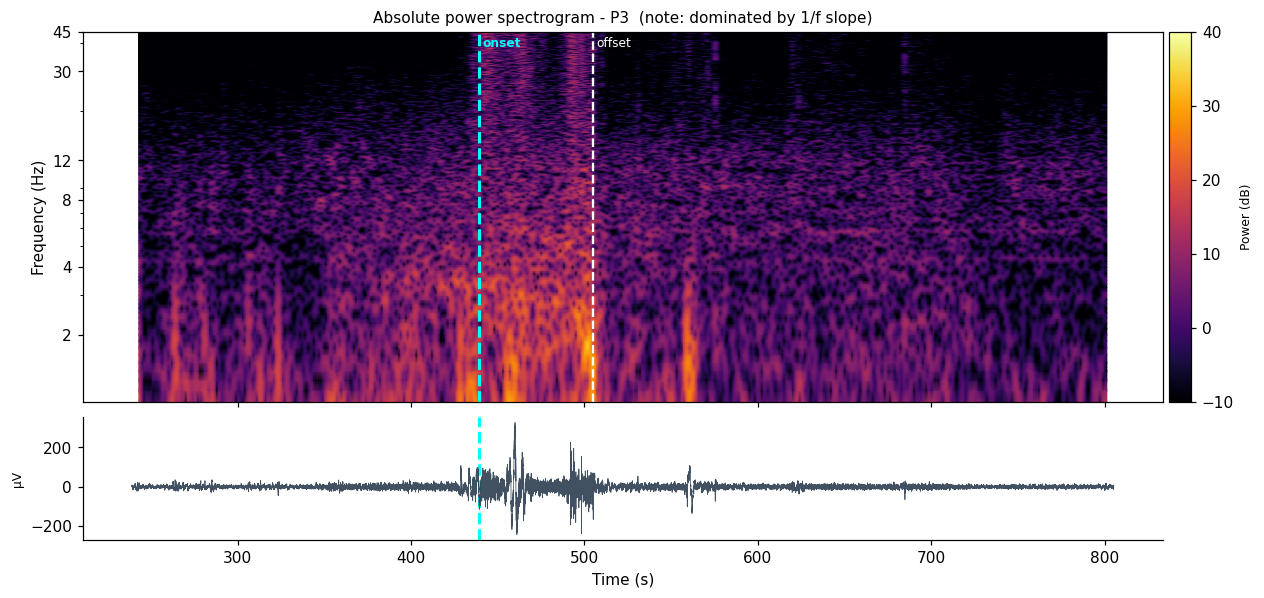

In [18]:
from mpl_toolkits.axes_grid1 import make_axes_locatable

ch_idx = raw_filt.ch_names.index(FOCUS_CH)

WIN_START = max(0,        (SZ_ONSET  - 200) if SZ_ONSET else 0)
WIN_END   = min(duration, (SZ_OFFSET + 300) if SZ_OFFSET else duration)

i0  = int(WIN_START * sfreq)
i1  = int(WIN_END   * sfreq)
sig = raw_filt.get_data(picks=[ch_idx])[0, i0:i1] * 1e6
t_raw = np.arange(len(sig)) / sfreq + WIN_START

nperseg  = int(8 * sfreq)
noverlap = int(7 * sfreq)   # 1 s hop
f_stft, t_stft, Sxx = sp.spectrogram(sig, fs=sfreq,
                                      nperseg=nperseg, noverlap=noverlap,
                                      window='hann')
times = t_stft + WIN_START
fmask = (f_stft >= 1) & (f_stft <= 45)

fig = plt.figure(figsize=(13, 6), facecolor='white')
gs  = gridspec.GridSpec(2, 1, height_ratios=[3, 1], hspace=0.06)
ax_tf  = fig.add_subplot(gs[0])
ax_eeg = fig.add_subplot(gs[1], sharex=ax_tf)

im = ax_tf.pcolormesh(times, f_stft[fmask],
                      10 * np.log10(Sxx[fmask] + 1e-30),
                      cmap='inferno', shading='gouraud',
                      vmin=-10, vmax=40, rasterized=True)

div_tf  = make_axes_locatable(ax_tf)
cax_tf  = div_tf.append_axes('right', size='2%', pad=0.06)
cb = plt.colorbar(im, cax=cax_tf)
cb.set_label('Power (dB)', fontsize=8)

div_eeg = make_axes_locatable(ax_eeg)
cax_eeg = div_eeg.append_axes('right', size='2%', pad=0.06)
cax_eeg.set_visible(False)

if SZ_ONSET is not None:
    for ax in (ax_tf, ax_eeg):
        ax.axvline(SZ_ONSET,  color='cyan',  lw=2, ls='--')
        ax.axvline(SZ_OFFSET, color='white', lw=1.5, ls='--')
    ax_tf.text(SZ_ONSET  + 2, f_stft[fmask][-1]*0.95, 'onset',
               color='cyan',  fontsize=8, va='top', fontweight='bold')
    ax_tf.text(SZ_OFFSET + 2, f_stft[fmask][-1]*0.95, 'offset',
               color='white', fontsize=8, va='top')

ax_tf.set_ylabel('Frequency (Hz)')
ax_tf.set_yscale('log')
ax_tf.set_yticks([2,4,8,12,30,45])
ax_tf.set_yticklabels(['2','4','8','12','30','45'])
ax_tf.tick_params(labelbottom=False)
ch_short = FOCUS_CH.replace('EEG ','').replace('-REF','')
ax_tf.set_title(f'Absolute power spectrogram - {ch_short}  (note: dominated by 1/f slope)', fontsize=10)

ax_eeg.plot(t_raw, sig, color='#2c3e50', lw=0.5, alpha=0.9)
ax_eeg.set_xlabel('Time (s)')
ax_eeg.set_ylabel('µV', fontsize=8)
ax_eeg.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.show()


---
### Questions - Section 5: Time-Frequency Analysis

**Q1.** You used an 8-second Hann window for the STFT. What is the frequency resolution
of this spectrogram (in Hz)? If you shorten the window to 2 seconds, what changes in the
frequency and time resolution? State the tradeoff as a general principle.

**Q2.** An IED - a spike-and-wave complex - lasts
roughly 100-200 ms. Can the STFT with an 8-second window detect individual IEDs?
What parameter would you change to make IEDs visible in the time-frequency map, and what
would you sacrifice?

---
## Section 6 - Baseline Normalization: Removing 1/f

> **Workshop slide:** *"Baseline Normalization"* - formula, color scale, baseline window choice.

$$P_{\text{norm}}(f, t) = 10 \cdot \log_{10} \frac{P(f, t)}{P_{\text{baseline}}(f)}$$

White = 0 dB (no change), red = increase, blue = decrease. Baseline window must be clean and well before seizure onset.

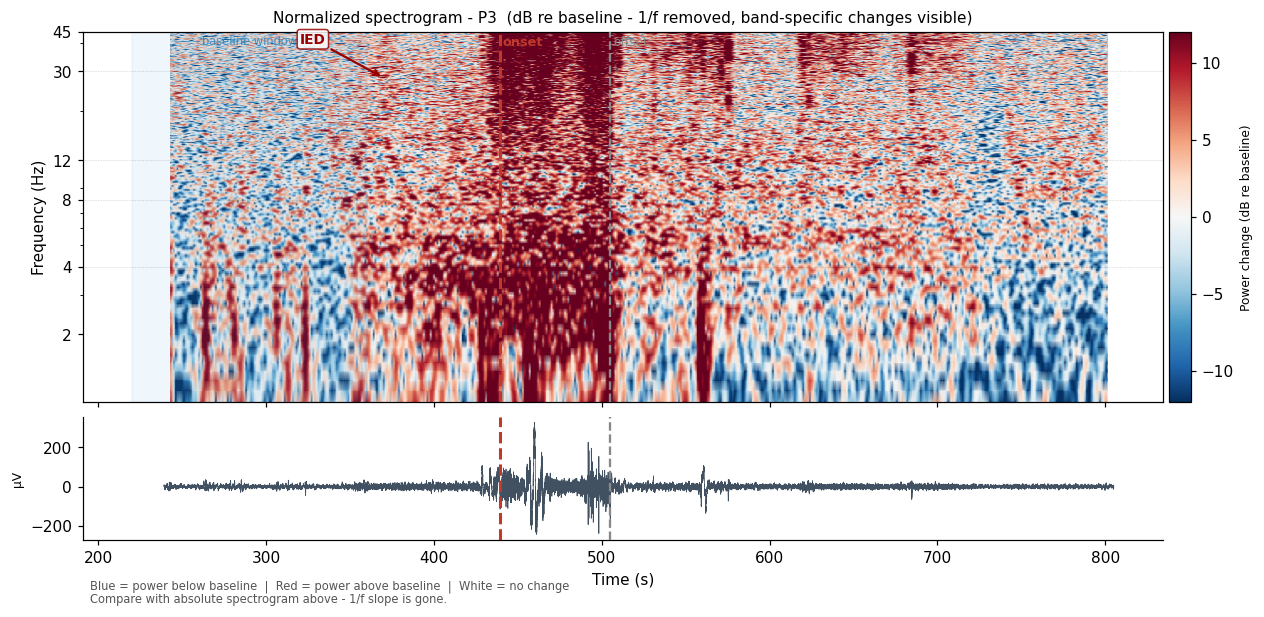

In [19]:
BL_START = 220.0
BL_END   = 360.0

bl_mask = (times >= BL_START) & (times <= BL_END)
baseline = np.median(Sxx[fmask][:, bl_mask], axis=1, keepdims=True)
power_db = 10 * np.log10(Sxx[fmask] / (baseline + 1e-30))
f_plot   = f_stft[fmask]

vmax = min(np.percentile(np.abs(power_db), 99), 12)

# Detect IED peak in β/γ band, pre-seizure window
hf_mask  = (f_plot >= 20) & (f_plot <= 45)
pre_mask = (times >= 320) & (times <= (SZ_ONSET - 20 if SZ_ONSET else times[-1]))
if pre_mask.any():
    hf_power = power_db[hf_mask][:, pre_mask].sum(axis=0)
    ied_t    = times[pre_mask][np.argmax(hf_power)]
else:
    ied_t = None

fig = plt.figure(figsize=(13, 6), facecolor='white')
gs  = gridspec.GridSpec(2, 1, height_ratios=[3, 1], hspace=0.06)
ax_tf  = fig.add_subplot(gs[0])
ax_eeg = fig.add_subplot(gs[1], sharex=ax_tf)

im = ax_tf.pcolormesh(times, f_plot, power_db,
                      cmap='RdBu_r', vmin=-vmax, vmax=vmax,
                      shading='gouraud', rasterized=True)

div_tf  = make_axes_locatable(ax_tf)
cax_tf  = div_tf.append_axes('right', size='2%', pad=0.06)
cb = plt.colorbar(im, cax=cax_tf)
cb.set_label('Power change (dB re baseline)', fontsize=8)

div_eeg = make_axes_locatable(ax_eeg)
cax_eeg = div_eeg.append_axes('right', size='2%', pad=0.06)
cax_eeg.set_visible(False)

# Baseline bracket
ax_tf.axvspan(BL_START, BL_END, color='#3498db', alpha=0.08)
ax_tf.text((BL_START+BL_END)/2, f_plot[-1]*0.88, 'baseline window',
           ha='center', color='#2980b9', fontsize=7.5, alpha=0.8)

# Band dividers
for name, fhi in [('δ',4),('θ',8),('α',12),('β',30)]:
    ax_tf.axhline(fhi, color='k', lw=0.4, ls=':', alpha=0.3)

if SZ_ONSET is not None:
    for ax in (ax_tf, ax_eeg):
        ax.axvline(SZ_ONSET,  color='#c0392b', lw=2, ls='--', zorder=5)
        ax.axvline(SZ_OFFSET, color='#888',    lw=1.5, ls='--', zorder=5)
    ax_tf.text(SZ_ONSET+2,  f_plot[-1]*0.96, 'onset',  color='#c0392b',
               fontsize=8.5, va='top', fontweight='bold')
    ax_tf.text(SZ_OFFSET+2, f_plot[-1]*0.96, 'offset', color='#888', fontsize=8, va='top')

if ied_t is not None:
    ax_tf.annotate('IED', xy=(ied_t, 28), xytext=(ied_t-50, 40),
                   fontsize=9, color='#900', fontweight='bold',
                   arrowprops=dict(arrowstyle='->', color='#900', lw=1.5),
                   bbox=dict(boxstyle='round,pad=0.2', fc='white', ec='#900', alpha=0.85))

ax_tf.set_ylabel('Frequency (Hz)')
ax_tf.set_yscale('log')
ax_tf.set_yticks([2,4,8,12,30,45])
ax_tf.set_yticklabels(['2','4','8','12','30','45'])
ax_tf.tick_params(labelbottom=False)
ax_tf.set_title(
    f'Normalized spectrogram - {ch_short}  '
    r'(dB re baseline - 1/f removed, band-specific changes visible)',
    fontsize=10)

ax_eeg.plot(t_raw, sig, color='#2c3e50', lw=0.5, alpha=0.9)
ax_eeg.set_xlabel('Time (s)')
ax_eeg.set_ylabel('µV', fontsize=8)
ax_eeg.spines[['top','right']].set_visible(False)

fig.text(0.13, 0.01,
         'Blue = power below baseline  |  Red = power above baseline  |  White = no change\n'
         'Compare with absolute spectrogram above - 1/f slope is gone.',
         fontsize=7.5, color='#555', va='bottom')

plt.tight_layout()
plt.show()


---
### Questions - Section 6: Baseline Normalization

**Q1.** The baseline window is defined as 140 seconds of pre-ictal EEG (220-360 s in this
recording). Name two scenarios where this specific baseline choice would produce a misleading
normalized spectrogram - cases where the "baseline" is not actually representative of the
normal brain state.

**Q2.** You are building a pre-ictal prediction model and want to normalize each epoch
relative to an inter-ictal reference. Why would using the 60 seconds immediately before
the seizure as your baseline be problematic? What baseline window would you use instead?


---
## Section 7 - Band Power: Pre / Ictal / Post

> **Workshop slide:** *"Band Power - Reference Values"* - standard bands, Welch parameters, expected ictal changes.

Welch PSD over three 60-second epochs (pre-ictal, ictal, post-ictal) on the focus channel.

In [20]:
BANDS = {
    'delta': (0.5,  4),
    'theta': (4,    8),
    'alpha': (8,   12),
    'beta' : (13,  30),
    'gamma': (30,  45),
}

_trapz = np.trapezoid if hasattr(np, 'trapezoid') else np.trapz

def band_power(freqs, psd, fmin, fmax):
    idx = (freqs >= fmin) & (freqs <= fmax)
    return _trapz(psd[idx], freqs[idx])

def get_epoch(raw_obj, t_start, t_end):
    ch_i = raw_obj.ch_names.index(FOCUS_CH)
    i0   = int(t_start * raw_obj.info['sfreq'])
    i1   = int(t_end   * raw_obj.info['sfreq'])
    return raw_obj.get_data(picks=[ch_i])[0, i0:i1] * 1e6

if SZ_ONSET is not None:
    sz_dur   = SZ_OFFSET - SZ_ONSET
    seg_pre  = get_epoch(raw_filt, SZ_ONSET  - 60, SZ_ONSET)
    seg_ict  = get_epoch(raw_filt, SZ_ONSET,        SZ_OFFSET)
    seg_post = get_epoch(raw_filt, SZ_OFFSET + 30,  SZ_OFFSET + 90)

    nperseg = int(4 * sfreq)
    fr, psd_pre  = sp.welch(seg_pre,  fs=sfreq, nperseg=nperseg)
    fr, psd_ict  = sp.welch(seg_ict,  fs=sfreq, nperseg=nperseg)
    fr, psd_post = sp.welch(seg_post, fs=sfreq, nperseg=nperseg)

    bp_pre  = {b: band_power(fr, psd_pre,  *r) for b, r in BANDS.items()}
    bp_ict  = {b: band_power(fr, psd_ict,  *r) for b, r in BANDS.items()}
    bp_post = {b: band_power(fr, psd_post, *r) for b, r in BANDS.items()}

    db_ict  = {b: 10 * np.log10(bp_ict[b]  / bp_pre[b]) for b in BANDS}
    db_post = {b: 10 * np.log10(bp_post[b] / bp_pre[b]) for b in BANDS}

    print('Band power change (dB vs pre-seizure):')
    print(f'  {"Band":8s}  {"Ictal":>8s}  {"Post-ictal":>10s}')
    for b in BANDS:
        print(f'  {b:8s}  {db_ict[b]:>+8.1f} dB  {db_post[b]:>+10.1f} dB')
else:
    print('No seizure defined — set SZ_ONSET/SZ_OFFSET in Section 0 to run this analysis.')

Band power change (dB vs pre-seizure):
  Band         Ictal  Post-ictal
  delta         +6.4 dB        -1.9 dB
  theta         +4.9 dB        -2.4 dB
  alpha         +4.3 dB        -0.5 dB
  beta          +7.5 dB        -1.2 dB
  gamma        +13.7 dB        +1.6 dB


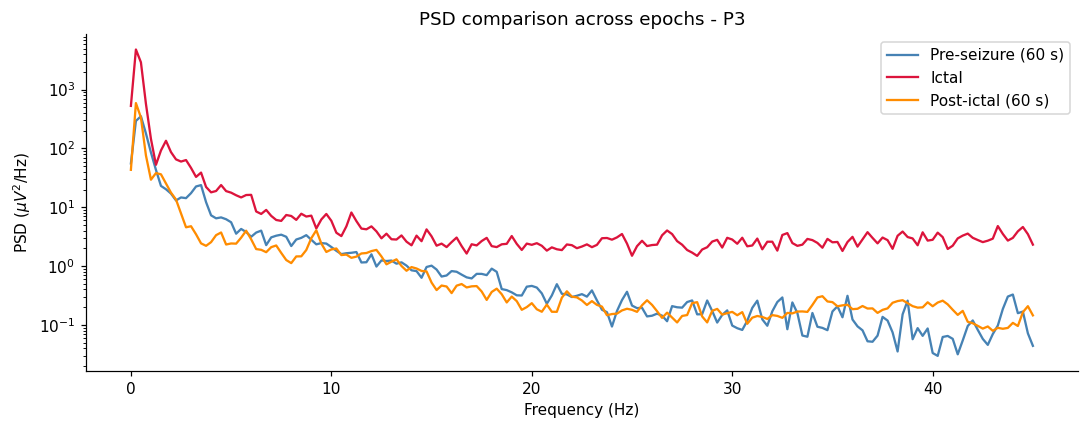

In [21]:
if SZ_ONSET is not None:
    mask70 = fr <= 45
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.semilogy(fr[mask70], psd_pre[mask70],  lw=1.5, color='steelblue',  label='Pre-seizure (60 s)')
    ax.semilogy(fr[mask70], psd_ict[mask70],  lw=1.5, color='crimson',    label='Ictal')
    ax.semilogy(fr[mask70], psd_post[mask70], lw=1.5, color='darkorange', label='Post-ictal (60 s)')
    ax.set_xlabel('Frequency (Hz)')
    ax.set_ylabel(r'PSD ($\mu V^2$/Hz)')
    ax.set_title(f'PSD comparison across epochs - {ch_short}')
    ax.legend()
    ax.spines[['top','right']].set_visible(False)
    plt.tight_layout()
    plt.show()

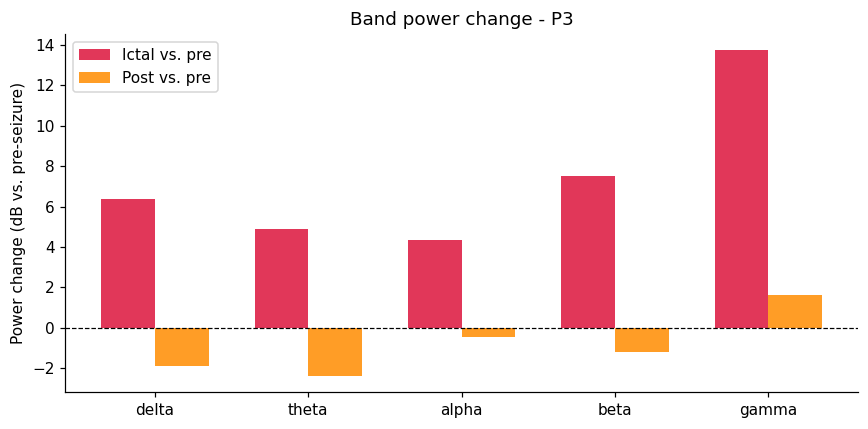

Largest ictal increase  : gamma (+13.7 dB)
Largest post-ictal drop : theta (-2.4 dB)


In [22]:
if SZ_ONSET is not None:
    band_names = list(BANDS.keys())
    x = np.arange(len(band_names))
    w = 0.35

    fig, ax = plt.subplots(figsize=(8, 4))
    ax.bar(x - w/2, [db_ict[b]  for b in band_names], w,
           label='Ictal vs. pre', color='crimson', alpha=0.85)
    ax.bar(x + w/2, [db_post[b] for b in band_names], w,
           label='Post vs. pre',  color='darkorange', alpha=0.85)
    ax.axhline(0, color='k', lw=0.8, ls='--')
    ax.set_xticks(x)
    ax.set_xticklabels(band_names)
    ax.set_ylabel('Power change (dB vs. pre-seizure)')
    ax.set_title(f'Band power change - {ch_short}')
    ax.legend()
    ax.spines[['top','right']].set_visible(False)
    plt.tight_layout()
    plt.show()

    print(f'Largest ictal increase  : {max(db_ict,  key=db_ict.get)}'  
          f' ({db_ict[max(db_ict,  key=db_ict.get)]:+.1f} dB)')
    print(f'Largest post-ictal drop : {min(db_post, key=db_post.get)}'
          f' ({db_post[min(db_post, key=db_post.get)]:+.1f} dB)')

> **Note - not all 36 "channels" are EEG.** TUAR EDFs also store reference/auxiliary
> signals (`A1`/`A2` ear refs, `ROC`/`LOC` eye movement, `EKG1`, `EMG`, `PHOTIC`) and
> TUH-derived event channels (`IBI`, `BURSTS`, `SUPPR`) that are not band-power-meaningful
> EEG - the latter three reach amplitudes of 10⁶-10⁸ µV. We restrict the multi-channel
> analyses below to the 19 standard 10-20 scalp channels.

In [23]:
# Restrict to real EEG scalp channels for multi-channel analyses (Sections 7-8)
NON_EEG = ['A1', 'A2', 'ROC', 'LOC', 'EKG', 'EMG', 'PHOTIC',
           '26-REF', '27-REF', '28-REF', '29-REF', '30-REF',
           'T1-REF', 'T2-REF', 'IBI', 'BURSTS', 'SUPPR']
eeg_chs = [c for c in raw_filt.ch_names if not any(x in c for x in NON_EEG)]
print(f'{len(eeg_chs)} EEG channels (of {len(raw_filt.ch_names)} total)')

19 EEG channels (of 36 total)


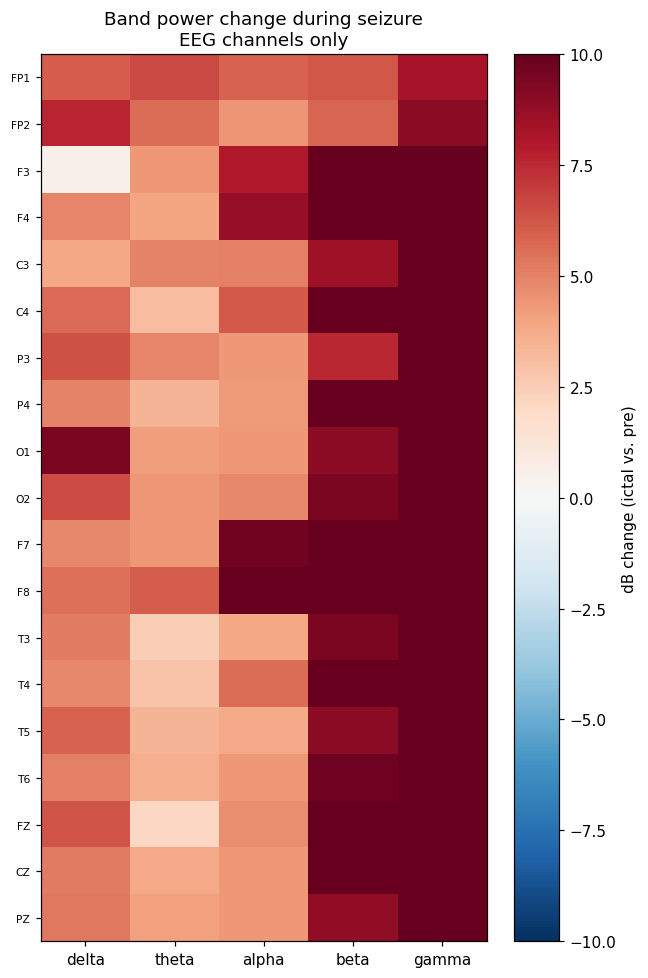

In [24]:
# Multi-channel band power heatmap (EEG channels only)
if SZ_ONSET is not None:
    eeg_idx_all = [raw_filt.ch_names.index(c) for c in eeg_chs]
    n_ch_eeg  = len(eeg_idx_all)
    nperseg   = int(4 * sfreq)
    db_matrix = np.zeros((n_ch_eeg, len(BANDS)))

    for ci, ch_i in enumerate(eeg_idx_all):
        seg_p = raw_filt.get_data(picks=[ch_i])[0,
                    int((SZ_ONSET-60)*sfreq):int(SZ_ONSET*sfreq)] * 1e6
        seg_i = raw_filt.get_data(picks=[ch_i])[0,
                    int(SZ_ONSET*sfreq):int(SZ_OFFSET*sfreq)] * 1e6
        fr2, p_pre = sp.welch(seg_p, fs=sfreq, nperseg=nperseg)
        fr2, p_ict = sp.welch(seg_i, fs=sfreq, nperseg=nperseg)
        for ji, (b, (flo, fhi)) in enumerate(BANDS.items()):
            pp = band_power(fr2, p_pre, flo, fhi)
            pi = band_power(fr2, p_ict, flo, fhi)
            db_matrix[ci, ji] = 10 * np.log10(pi / (pp + 1e-30))

    ch_labels = [c.replace('EEG ','').replace('-REF','') for c in eeg_chs]

    fig, ax = plt.subplots(figsize=(6, 9))
    im = ax.imshow(db_matrix, aspect='auto', cmap='RdBu_r', vmin=-10, vmax=10)
    plt.colorbar(im, ax=ax, label='dB change (ictal vs. pre)')
    ax.set_yticks(range(n_ch_eeg))
    ax.set_yticklabels(ch_labels, fontsize=7)
    ax.set_xticks(range(len(BANDS)))
    ax.set_xticklabels(list(BANDS.keys()))
    ax.set_title('Band power change during seizure\nEEG channels only')
    plt.tight_layout()
    plt.show()

---
### Questions - Section 7: Band Power

**Q1.** Look at the bar chart. Which band shows the largest relative increase during the
seizure? Does that match what you saw in the normalized spectrogram in Section 6?

**Q2.** You compute Welch PSD over the entire ictal epoch (66 s). What is the minimum
frequency you can resolve with a default 8 s Welch segment? What alternative time-frequency
method from the lecture handles short or non-stationary epochs better, and why?


---
## Section 8 - Building an ML-Ready Dataset

> **Workshop slides:** *"Windowing and Labelling"*, *"Class Imbalance"*

Divide the filtered signal into 4 s windows (2 s hop), label each window (`1` = seizure if >= 50% overlap, `0` = background), extract band-power features (5 bands x N channels), save to disk.

**Note:** only the first seizure (439-505 s) is labelled here. The second seizure (940-1058 s) is left as an exercise.


In [25]:
WIN_S  = 4.0   # window length (seconds)
HOP_S  = 2.0   # hop size (seconds) — 50% overlap
THRESH = 0.5   # fraction of window that must overlap seizure to be labelled 1

WIN_SAMP = int(WIN_S * sfreq)
HOP_SAMP = int(HOP_S * sfreq)

print(f"Window : {WIN_S} s = {WIN_SAMP} samples")
print(f"Hop    : {HOP_S} s = {HOP_SAMP} samples")
print(f"Channels included: {len(eeg_chs)}  (EEG only)")
print(f"Bands  : {list(BANDS.keys())}")

Window : 4.0 s = 1000 samples
Hop    : 2.0 s = 500 samples
Channels included: 19  (EEG only)
Bands  : ['delta', 'theta', 'alpha', 'beta', 'gamma']


In [26]:
eeg_idx_all = [raw_filt.ch_names.index(c) for c in eeg_chs]
data_filt_all = raw_filt.get_data(picks=eeg_idx_all) * 1e6   # (n_eeg_ch, n_samples)
n_ch_all, n_samp = data_filt_all.shape
n_bands = len(BANDS)

# Window start indices
starts = np.arange(0, n_samp - WIN_SAMP + 1, HOP_SAMP)
n_win  = len(starts)
print(f"Total windows: {n_win}")

# Pre-allocate feature matrix and label vector
X = np.zeros((n_win, n_ch_all * n_bands))   # one row per window
y = np.zeros(n_win, dtype=int)

nperseg_w = min(int(2 * sfreq), WIN_SAMP)   # Welch segment within each window

for wi, i0 in enumerate(starts):
    i1      = i0 + WIN_SAMP
    t_start = i0 / sfreq
    t_end   = i1 / sfreq

    # ── Label ────────────────────────────────────────────────────────────
    if SZ_ONSET is not None:
        overlap = max(0, min(t_end, SZ_OFFSET) - max(t_start, SZ_ONSET))
        y[wi]   = 1 if overlap / WIN_S >= THRESH else 0

    # ── Features: band power per channel ─────────────────────────────────
    feat = []
    for ch_sig in data_filt_all[:, i0:i1]:
        fr_w, psd_w = sp.welch(ch_sig, fs=sfreq, nperseg=nperseg_w)
        feat.extend(band_power(fr_w, psd_w, flo, fhi)
                    for flo, fhi in BANDS.values())
    X[wi] = feat

print(f"X shape : {X.shape}  (windows × features)")
print(f"y shape : {y.shape}")
print(f"Seizure windows    : {y.sum()}  ({y.mean()*100:.1f}%)")
print(f"Background windows : {(y==0).sum()}  ({(y==0).mean()*100:.1f}%)")

Total windows: 720
X shape : (720, 95)  (windows × features)
y shape : (720,)
Seizure windows    : 33  (4.6%)
Background windows : 687  (95.4%)


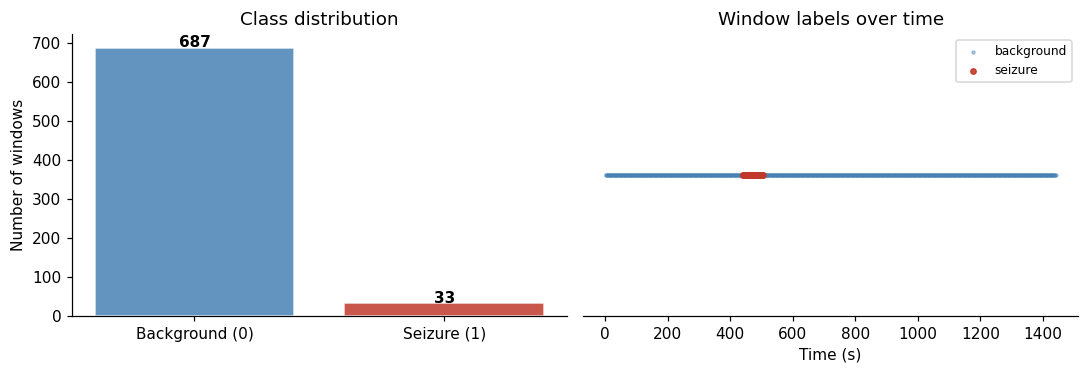

Class imbalance ratio: 21:1  (background:seizure)
This imbalance must be addressed during model training (weighting, oversampling, etc.)


In [27]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))

# Class distribution bar chart
counts = [(y == 0).sum(), (y == 1).sum()]
axes[0].bar(["Background (0)", "Seizure (1)"], counts,
            color=["steelblue", "#c0392b"], alpha=0.85, edgecolor="white")
for i, c in enumerate(counts):
    axes[0].text(i, c + 1, str(c), ha="center", fontsize=10, fontweight="bold")
axes[0].set_ylabel("Number of windows")
axes[0].set_title("Class distribution")
axes[0].spines[["top","right"]].set_visible(False)

# Label timeline — shows where seizure windows fall
t_centres = (starts + WIN_SAMP // 2) / sfreq
axes[1].scatter(t_centres[y == 0], np.zeros((y==0).sum()),
                c="steelblue", s=4, alpha=0.4, label="background")
axes[1].scatter(t_centres[y == 1], np.zeros((y==1).sum()),
                c="#c0392b", s=12, alpha=0.9, label="seizure")
axes[1].set_xlabel("Time (s)")
axes[1].set_yticks([])
axes[1].set_title("Window labels over time")
axes[1].legend(fontsize=8)
axes[1].spines[["top","right","left"]].set_visible(False)

plt.tight_layout()
plt.show()

ratio = (y==0).sum() / max(y.sum(), 1)
print(f"Class imbalance ratio: {ratio:.0f}:1  (background:seizure)")
print("This imbalance must be addressed during model training (weighting, oversampling, etc.)")


---
### Question - Section 8

**Q1.** This recording has a second seizure from 940 s to 1058 s. Extend the labeling code above to include it. How many additional seizure windows do you get, and how does that change the class imbalance ratio?


In [28]:
import os
os.makedirs("dataset", exist_ok=True)

np.save("dataset/X_s1.npy", X)
np.save("dataset/y_s1.npy", y)

# Save metadata alongside the feature arrays
import json as _json
meta = {
    "bname":      BNAME,
    "win_s":      WIN_S,
    "hop_s":      HOP_S,
    "sfreq":      sfreq,
    "channels":   raw_filt.ch_names,
    "bands":      {b: list(r) for b, r in BANDS.items()},
    "n_features": X.shape[1],
    "n_windows":  X.shape[0],
    "n_seizure":  int(y.sum()),
}
with open("dataset/meta_s1.json", "w") as f:
    _json.dump(meta, f, indent=2)

print("Saved:")
print(f"  dataset/X_s1.npy   {X.shape}")
print(f"  dataset/y_s1.npy   {y.shape}")
print(f"  dataset/meta_s1.json")
print()
print("Load in any other notebook with:")
print("  X = np.load('dataset/X_s1.npy')")
print("  y = np.load('dataset/y_s1.npy')")

Saved:
  dataset/X_s1.npy   (720, 95)
  dataset/y_s1.npy   (720,)
  dataset/meta_s1.json

Load in any other notebook with:
  X = np.load('dataset/X_s1.npy')
  y = np.load('dataset/y_s1.npy')


---
## What's Next

The dataset you just saved (`dataset/X_s1.npy`, `dataset/y_s1.npy`) and the preprocessing
decisions you made here feed directly into **Project 1**.

Open **`EEG_02_Seizure_Detection_DL.ipynb`** to:
- Load a TUSZ seizure recording and build a windowed dataset (same pipeline as Section 8)
- Train an MLP on band-power features
- Train a 1D-CNN on the raw signal (no feature engineering)
- Compare: does ICA preprocessing actually help, or can the model learn around artifacts?
- Evaluate under realistic online (time-split) conditions and on a held-out patient
- Apply the trained model to the Yobe hospital recording
